# Stochastic Modeling of Customer Churn using Markov Chains

### Setup and Data Loading

In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load and clean
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [7]:
def categorize_state(row):
    if row['Churn'] == 'Yes': return 'Churned'
    elif row['Contract'] == 'Month-to-month': return 'AtRisk'
    else: return 'Active'

df['state'] = df.apply(categorize_state, axis=1)
print(f"State Distribution:\n{df['state'].value_counts(normalize=True)}")

State Distribution:
state
Active     0.419424
AtRisk     0.315207
Churned    0.265370
Name: proportion, dtype: float64


### The Transition Matrix

In [8]:
states = ['Active', 'AtRisk', 'Churned']
P = pd.DataFrame([
    [0.85, 0.12, 0.03], # Active transitions
    [0.20, 0.50, 0.30], # AtRisk transitions
    [0.00, 0.00, 1.00]  # Churned is absorbing
], index=states, columns=states)

print("Transition Matrix P:")
display(P)

# Verification of Row Stochasticity
assert np.allclose(P.sum(axis=1), 1.0), "Rows must sum to 1!"

Transition Matrix P:


,Active,AtRisk,Churned
Active,0.85,0.12,0.03
AtRisk,0.20,0.50,0.30
Churned,0.00,0.00,1.00


### State Space Analysis

In [9]:
# Partitioning
Q = P.iloc[0:2, 0:2].values
R = P.iloc[0:2, 2:3].values
I = np.eye(len(Q))

# Fundamental Matrix N = (I - Q)^-1
N = np.linalg.inv(I - Q)
N_df = pd.DataFrame(N, index=['Active', 'AtRisk'], columns=['Active', 'AtRisk'])

# B = N * R (Hitting Probabilities)
B = N @ R

# mu = N * 1 (Mean Hitting Times)
mu = N @ np.ones(len(Q))

print("Fundamental Matrix N (Expected months in each state):")
display(N_df)
print(f"\nProb. of Churn from Active: {B[0][0]:.2%}")
print(f"Expected months until Churn (Active): {mu[0]:.2f}")

Fundamental Matrix N (Expected months in each state):


,Active,AtRisk
Active,9.803922,2.352941
AtRisk,3.921569,2.941176



Prob. of Churn from Active: 100.00%
Expected months until Churn (Active): 12.16


### Visualization

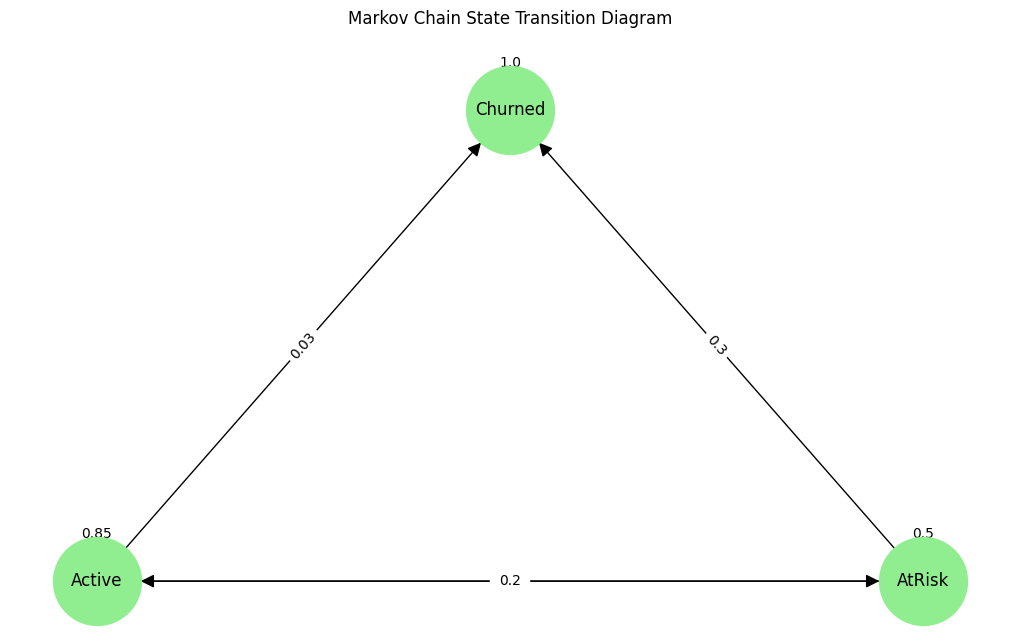

In [10]:
G = nx.DiGraph()
for i in P.index:
    for j in P.columns:
        if P.loc[i, j] > 0:
            G.add_edge(i, j, weight=P.loc[i, j])

pos = nx.planar_layout(G)
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_size=4000, node_color='lightgreen', font_size=12, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Markov Chain State Transition Diagram")
plt.show()

### Convergence Simulation

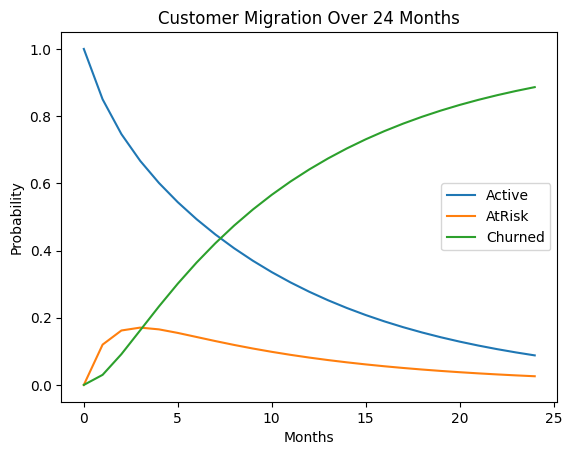

Final State after 2 years:
Active     0.087907
AtRisk     0.025809
Churned    0.886284
Name: 24, dtype: float64


In [11]:
v = np.array([1.0, 0.0, 0.0]) # Start all customers as 'Active'
history = [v]

for _ in range(24): # Simulate 2 years
    v = v @ P.values
    history.append(v)

history_df = pd.DataFrame(history, columns=states)
history_df.plot(title="Customer Migration Over 24 Months")
plt.xlabel("Months")
plt.ylabel("Probability")
plt.show()

print(f"Final State after 2 years:\n{history_df.iloc[-1]}")